AI-Powered Employee Attrition Prediction System
Kaggle Dataset
🏆 IBM HR Analytics Employee Attrition & Performance
Kaggle:
 https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Real Business Problem
An organization loses employees every month.
HR wants to predict:
Which employees are likely to leave
Why they may leave
Which factors influence attrition
Risk category of employees

Student Deliverables
Phase 1 — EDA
Identify:
Attrition rate
Department-wise attrition
Gender-wise attrition
Salary impact
Experience impact

Phase 2 — Machine Learning
Logistic Regression
Predict:
Attrition = Yes / No

Decision Tree
Generate HR decision rules.
Example:
IF
JobSatisfaction < 2
AND
MonthlyIncome < 4000

THEN
High Attrition Risk

Random Forest
Build production model.

SVM
Compare accuracy.

KNN
Find similar employees.

Naive Bayes
Probability-based prediction.

PCA
Dimensionality reduction.

K-Means
Employee Segmentation:
Cluster 1:
High Performers

Cluster 2:
At Risk

Cluster 3:
New Employees

AWS Requirements
S3
Store:
dataset/
model/
reports/

SageMaker
Train:
logistic_regression.pkl
random_forest.pkl

Endpoint
Deploy:
employee-attrition-predictor

Lambda
Input:
{
 "Age": 35,
 "MonthlyIncome": 4500,
 "JobSatisfaction": 2
}

API Gateway
POST /predict

Output
{
 "attrition_probability": 87.3,
 "risk_level": "HIGH"
}


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Nishath Tabassum\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [3]:
import os
import kagglehub

path = kagglehub.dataset_download(
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)

print("Dataset Path:", path)
print("Files:", os.listdir(path))

Dataset Path: C:\Users\Nishath Tabassum\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1
Files: ['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [4]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Nishath Tabassum\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1\WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

print(df.head())
print(df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score

import joblib

Check Target Column

In [5]:
print(df["Attrition"].unique())

print(df["Attrition"].value_counts())

['Yes' 'No']
Attrition
No     1233
Yes     237
Name: count, dtype: int64


Attrition Rate

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


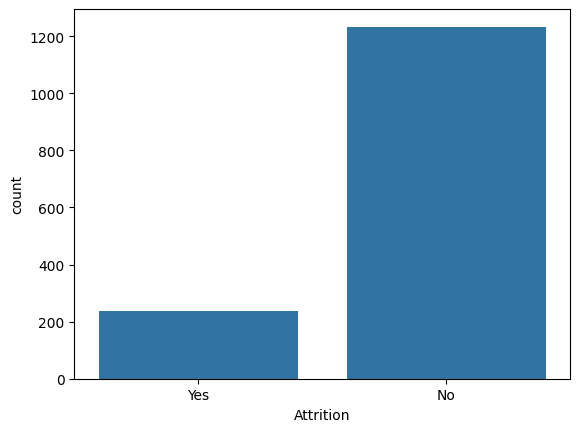

In [6]:
attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)
    * 100
)

print(attrition_rate)

sns.countplot(
    x="Attrition",
    data=df
)

plt.show()

Department-wise Attrition

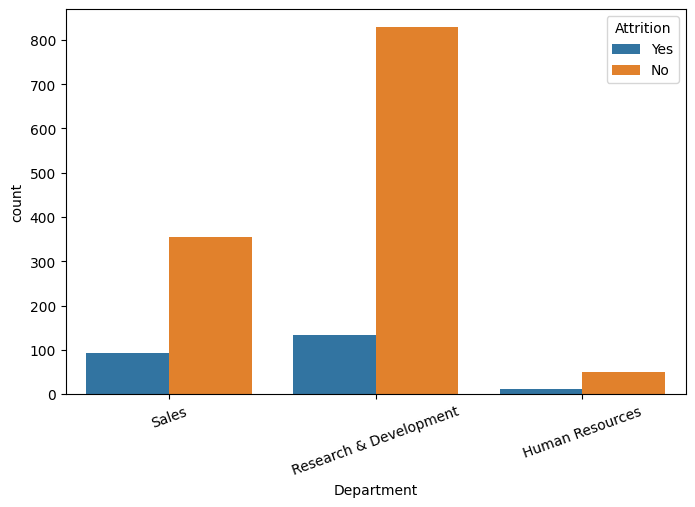

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=20)

plt.show()

Gender-wise Attrition

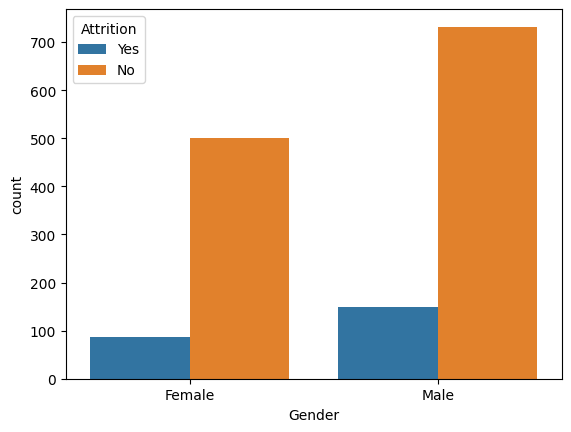

In [8]:
sns.countplot(
    x="Gender",
    hue="Attrition",
    data=df
)

plt.show()

Salary Impact

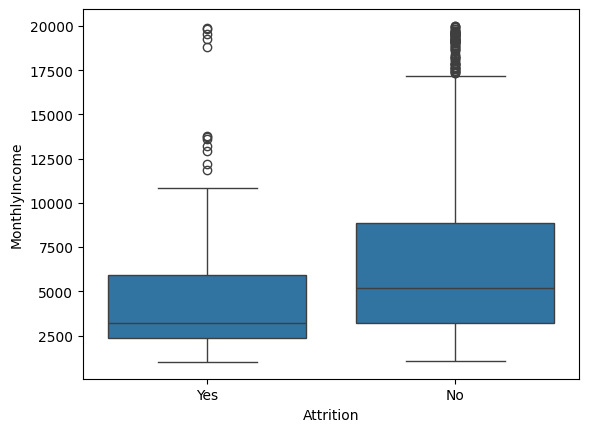

In [9]:
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.show()

Experience Impact

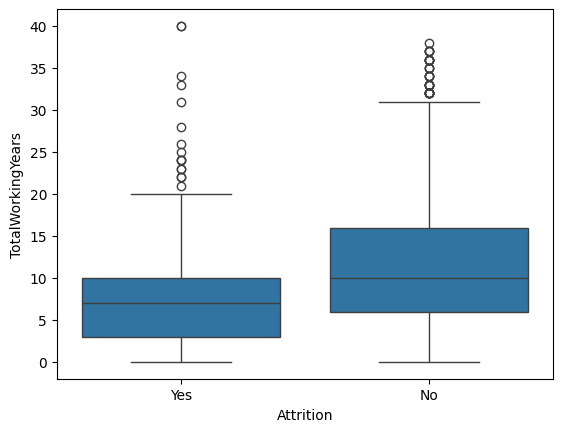

In [10]:
sns.boxplot(
    x="Attrition",
    y="TotalWorkingYears",
    data=df
)

plt.show()

Convert Target

In [11]:
df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print(df["Attrition"].isna().sum())

print(df["Attrition"].value_counts())

0
Attrition
0    1233
1     237
Name: count, dtype: int64


Features and Target

In [12]:
X = df.drop(
    "Attrition",
    axis=1
)

y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 34)
(1470,)


Encode Categorical Features

In [13]:
for col in X.select_dtypes(
    include="object"
).columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col]
    )

In [14]:
print(
    X.select_dtypes(
        include="object"
    ).columns
)

Index([], dtype='object')


Train-Test Split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 34)
(294, 34)


Scale Features

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

Logistic Regression

In [17]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

pred_lr = lr.predict(
    X_test_scaled
)

print(
    "Logistic Accuracy:",
    accuracy_score(
        y_test,
        pred_lr
    )
)

Logistic Accuracy: 0.8741496598639455


Decision Tree

In [18]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

pred_dt = dt.predict(
    X_test
)

print(
    "Decision Tree Accuracy:",
    accuracy_score(
        y_test,
        pred_dt
    )
)

Decision Tree Accuracy: 0.8435374149659864


Decision Rules

In [19]:
rules = export_text(
    dt,
    feature_names=list(X.columns)
)

print(rules)

|--- TotalWorkingYears <= 1.50
|   |--- Age <= 33.50
|   |   |--- OverTime <= 0.50
|   |   |   |--- HourlyRate <= 58.50
|   |   |   |   |--- PercentSalaryHike <= 21.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- PercentSalaryHike >  21.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- HourlyRate >  58.50
|   |   |   |   |--- HourlyRate <= 73.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- HourlyRate >  73.50
|   |   |   |   |   |--- class: 0
|   |   |--- OverTime >  0.50
|   |   |   |--- MaritalStatus <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- MaritalStatus >  0.50
|   |   |   |   |--- DailyRate <= 297.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- DailyRate >  297.00
|   |   |   |   |   |--- class: 1
|   |--- Age >  33.50
|   |   |--- JobSatisfaction <= 2.00
|   |   |   |--- class: 1
|   |   |--- JobSatisfaction >  2.00
|   |   |   |--- class: 0
|--- TotalWorkingYears >  1.50
|   |--- OverTime <= 0.50
|   |   |--- WorkLifeBalance <= 1.50

Random Forest

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        pred_rf
    )
)

Random Forest Accuracy: 0.8333333333333334


SVM

In [21]:
svm = SVC()

svm.fit(
    X_train_scaled,
    y_train
)

pred_svm = svm.predict(
    X_test_scaled
)

print(
    "SVM Accuracy:",
    accuracy_score(
        y_test,
        pred_svm
    )
)

SVM Accuracy: 0.8639455782312925


KNN

In [22]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

pred_knn = knn.predict(
    X_test_scaled
)

print(
    "KNN Accuracy:",
    accuracy_score(
        y_test,
        pred_knn
    )
)

KNN Accuracy: 0.8469387755102041


Naive Bayes

In [23]:
nb = GaussianNB()

nb.fit(
    X_train_scaled,
    y_train
)

pred_nb = nb.predict(
    X_test_scaled
)

print(
    "Naive Bayes Accuracy:",
    accuracy_score(
        y_test,
        pred_nb
    )
)

Naive Bayes Accuracy: 0.7380952380952381


PCA

In [24]:
pca = PCA(
    n_components=0.95
)

X_pca = pca.fit_transform(
    X_train_scaled
)

print(
    "Reduced Features:",
    X_pca.shape[1]
)

Reduced Features: 24


K-Means

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_train_scaled
)

print(clusters[:20])

[0 1 0 1 0 1 1 0 1 1 2 0 0 1 2 2 0 1 1 0]


Save Models

In [26]:
joblib.dump(
    rf,
    "random_forest.pkl"
)

joblib.dump(
    lr,
    "logistic_regression.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

Risk Prediction

In [27]:
sample = X_test.iloc[[0]]

prob = rf.predict_proba(
    sample
)[0][1] * 100

print(
    "Attrition Probability:",
    round(prob,2)
)

if prob >= 75:
    risk = "HIGH"
elif prob >= 40:
    risk = "MEDIUM"
else:
    risk = "LOW"

print(
    "Risk Level:",
    risk
)

Attrition Probability: 53.5
Risk Level: MEDIUM


Test Accuracy

In [28]:
print("Logistic Regression:",
      accuracy_score(y_test,pred_lr))

print("Decision Tree:",
      accuracy_score(y_test,pred_dt))

print("Random Forest:",
      accuracy_score(y_test,pred_rf))

print("SVM:",
      accuracy_score(y_test,pred_svm))

print("KNN:",
      accuracy_score(y_test,pred_knn))

print("Naive Bayes:",
      accuracy_score(y_test,pred_nb))

Logistic Regression: 0.8741496598639455
Decision Tree: 0.8435374149659864
Random Forest: 0.8333333333333334
SVM: 0.8639455782312925
KNN: 0.8469387755102041
Naive Bayes: 0.7380952380952381


In [29]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print(prediction)

[1]


In [30]:
prob = rf.predict_proba(sample)

print(prob)

[[0.465 0.535]]


In [31]:
attrition_probability = prob[0][1] * 100

print(attrition_probability)

53.5


In [32]:
prob = rf.predict_proba(sample)[0][1] * 100

if prob >= 75:
    risk = "HIGH"
elif prob >= 40:
    risk = "MEDIUM"
else:
    risk = "LOW"

print("Risk:", risk)

Risk: MEDIUM


In [33]:
probs = rf.predict_proba(X_test)[:,1]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": probs
})

results = results.sort_values(
    by="Probability",
    ascending=False
)

print(results.head(10))

     Actual  Probability
200       1        0.920
92        1        0.780
223       0        0.730
276       1        0.615
9         0        0.575
214       1        0.560
239       0        0.550
241       0        0.540
189       0        0.535
0         0        0.535
